# Vedant - Example

How to run contacts using the brahe library, with some additional functions in this repository!

First, make sure to install the brahe library:

```bash
pip install git+https://github.com/duncaneddy/brahe.git@master matplotlib ipympl cartopy
```

## Setup Imports

(not relevant to repo, can skip) 

Adding module path to run correctly in examples folder

In [3]:
import sys
import os

# Add the path to the folder containing the module
module_path = os.path.abspath(os.path.join('..'))
print(module_path)
if module_path not in sys.path:
    sys.path.append(module_path)

/Users/vedantsrinivas/Documents/loc-gsopt/src


## Imports & Downloading latest Earth Orientation Data

In [4]:
from common.sat_gen import make_tle
from common.station_gen import teleport_json
from common.utils import load_earth_data, compute_all_gaps_contacts

# Brahe Imports
import brahe as bh
import brahe.data_models as bdm
import brahe.access.access as ba
import numpy as np 
%matplotlib inline

import matplotlib.pyplot as plt

# Setup info
load_earth_data('data/iau2000A_finals_ab.txt')

Loading the latest Earth Orientation Data


## Generate Satellites Using TLEs

In [5]:
##### Trying to generate a satellite just through tles ######

# Create a TLE
epc0 = bh.Epoch(2024, 5, 20, 0, 0, 0) # This is the epoch of the orbital elements
alt  = 550 # Altitude in km
ecc  = 0.01 # Eccentricity - Generally don't want it to be 0, so give it a small value 0.0001 to 0.01
inc  = 53 # Inclination in degrees
raan = 15 # Right Ascension of the Ascending Node in degrees
argp = 30 # Argument of Perigee in degrees
M    = 45 # Mean Anomaly in degrees
norad_id = 99999 # NORAD ID of the satellite - This is just a placeholder, but we need a number.

tle = make_tle(epc0, alt, ecc, inc, raan, argp, M, norad_id=norad_id)

print(f'Our TLE looks like:\n {tle.line1}\n {tle.line2}\n')

sat1 = bdm.Spacecraft(
    id=99999, # Might need to change this at one point
    name="Sat1",
    line1=tle.line1,
    line2=tle.line2,
)

Our TLE looks like:
 1 99999U          24141.00000000  .00000000  00000-0  00000-0 0    00
 2 99999  53.0000  15.0000 0100000  30.0000  45.0000 15.05490874    07



## Load Ground Station Locations and Compute Contacts

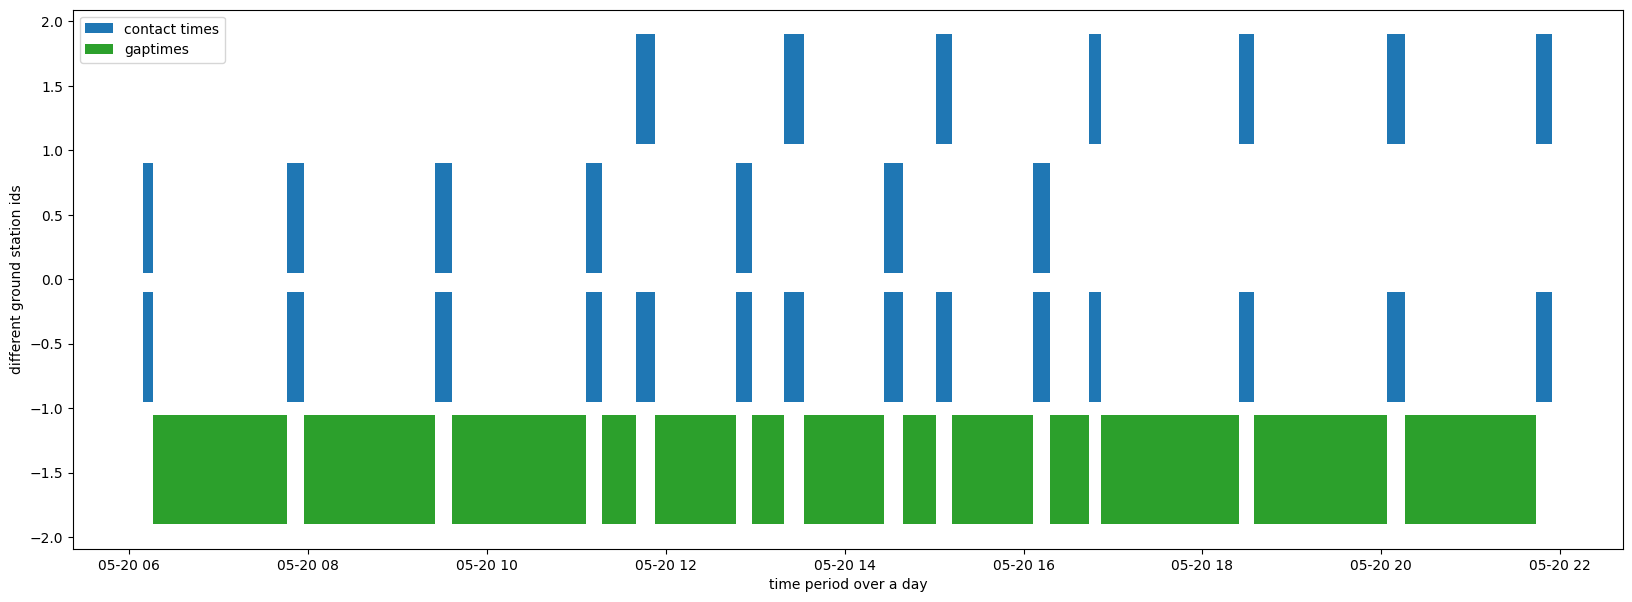

In [120]:
fig, ax = fig, ax =  plt.subplots(figsize=(20,7))

# Ground station Locations
stations = teleport_json('data/teleport_locations.json')

# Computing Contacts for only one day
epc1 = epc0 + 86400 # seconds in a day

contacts_all = []

######################## Plotting specific! ####################

# going through computing contacts for all stations and all 
for station,id in zip(stations[0:2],range(len(stations[0:2]))):
    contacts = ba.find_location_accesses(sat1,station,epc0,epc1)
    for contact in contacts:
        contacts_all.append(contact)
    ax.broken_barh([(contacts[i].t_start,contacts[i].t_end-contacts[i].t_start) for i in range(len(contacts))], (id+0.05, 0.85),facecolors='tab:blue')

ax.broken_barh([(contacts_all[i].t_start,contacts_all[i].t_end-contacts_all[i].t_start) for i in range(len(contacts_all))], (-0.95, 0.85),facecolors='tab:blue', label = "contact times")

sorted_contacts = sorted(contacts_all, key=lambda t: t.t_start)
all_gap_times = []

current_t_end = sorted_contacts[0].t_end
for contact in sorted_contacts:
    if current_t_end < contact.t_end and current_t_end > contact.t_start:
        current_t_end = contact.t_end
    if current_t_end < contact.t_start:
        all_gap_times.append((current_t_end,contact.t_start))
        current_t_end = contact.t_end

ax.broken_barh([(all_gap_times[i][0],all_gap_times[i][1]-all_gap_times[i][0]) for i in range(len(all_gap_times))], (-1.9, 0.85),facecolors='tab:green',label = "gaptimes")

plt.ylabel("different ground station ids")
plt.xlabel("time period over a day")
plt.legend()
plt.show()

######################## Plotting specific! ####################



### Just to see the gap times:

In [63]:
_, _, gaps_seconds = compute_all_gaps_contacts([sat1], stations[0:5] ,epc0, epc1, False)
print(gaps_seconds)

[5382.916571, 5289.869696, 5382.753607, 5406.343085, 5299.409491, 5224.502874, 22164.376831, 27729.250453, 5181.40351, 5301.822821, 5522.906195, 5541.165472, 5348.959661, 5251.737982, 42010.208129, 7512.47494, 5306.918646, 5516.605536, 11916.026312, 5558.959662, 5245.871283, 5456.427923, 16162.053222, 27616.019862, 5341.247259, 36607.68891, 5219.670722, 30444.655462, 4008.927612, 1849.585548, 5329.032293, 36321.07392, 5225.608832, 4134.697265, 32647.420332]


In [64]:
np.mean(gaps_seconds)

np.float64(11813.102626257143)

In [124]:
#Input parameters
import gurobipy as gp 
from gurobipy import GRB

#Initialize model
m = gp.Model("Pick stations")

#Initialize binary variables on whether or not we should choose the station
x = {}
for i, station in enumerate(stations):
    x[i] = m.addVar(vtype=GRB.BINARY, name=f"station_{i}")

#add max stations constraint
MAX_STATIONS = 10
m.addConstr(sum(x.values()) <= MAX_STATIONS, "max_stations")

#Create the station_contacts dictionary- mapping the station index to the station itself and it's contact points
station_contacts = {}
for i, station in enumerate(stations):
    contacts = ba.find_location_accesses(sat1, station, epc0, epc1)
    station_contacts[i] = [(contact, i, station) for contact in contacts]

all_contacts_with_stations = []
for station_id, contact_list in station_contacts.items():
    all_contacts_with_stations.extend(contact_list)
#Sort by start time
sorted_contacts_with_stations = sorted(all_contacts_with_stations, key=lambda x: x[0].t_start)

#M = epc1 - epc0
max_gap = m.addVar(name="max_gap")

#For each station, calculate the gap time with the next contact point for the next station
for i in range(len(sorted_contacts_with_stations) - 1):
    #Get contact information
    current_contact, current_station_id, current_station = sorted_contacts_with_stations[i]
    next_contact, next_station_id, next_station = sorted_contacts_with_stations[i+1]
    #Calculate gap time between current contact and the next contact
    gap = (next_contact.t_start - current_contact.t_end).total_seconds()

    #Adds the constraint that if both stations are selected then the gap has to be less than the maximum
    #gap, and if only one or neither are selected the condition is trivial and becomes satisfied
    m.addConstr(max_gap >= gap * (x[current_station_id] + x[next_station_id] - 1))

m.setObjective(max_gap, GRB.MINIMIZE)
m.optimize()

#Print the solution
if m.status == GRB.OPTIMAL:
    print("\nOptimal solution found!")
    print(f"\nMaximum gap time: {max_gap.X:.2f} seconds")

    print("\nSelected ground stations:")
    for i in x:
        if x[i].X > 0.5:  
            print(f"Station {i}")
            
    # Print all gaps in the optimal solution
    print("\nGaps between contacts using selected stations:")
    for i in range(len(sorted_contacts_with_stations) - 1):
        current_contact, current_station_id, current_station = sorted_contacts_with_stations[i]
        next_contact, next_station_id, next_station = sorted_contacts_with_stations[i + 1]
        
        # Only show gaps between selected stations
        if x[current_station_id].X > 0.5 and x[next_station_id].X > 0.5:
            gap = (next_contact.t_start - current_contact.t_end).total_seconds()
            print(f"Gap between station {current_station.station_name} and {next_station.station_name}: {gap:.2f} seconds")

else:
    print("No optimal solution found")



Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (mac64[arm] - Darwin 22.5.0 22F82)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 5842 rows, 916 columns and 18438 nonzeros
Model fingerprint: 0xc99df536
Variable types: 1 continuous, 915 integer (915 binary)
Coefficient statistics:
  Matrix range     [7e-01, 1e+03]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [7e-01, 1e+03]
Found heuristic solution: objective 824.1668701
Found heuristic solution: objective 824.1668700
Presolve removed 2174 rows and 2 columns
Presolve time: 0.04s
Presolved: 3668 rows, 914 columns, 11914 nonzeros
Variable types: 1 continuous, 913 integer (913 binary)

Root relaxation: objective 7.491180e+02, 610 iterations, 0.05 seconds (0.08 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

     

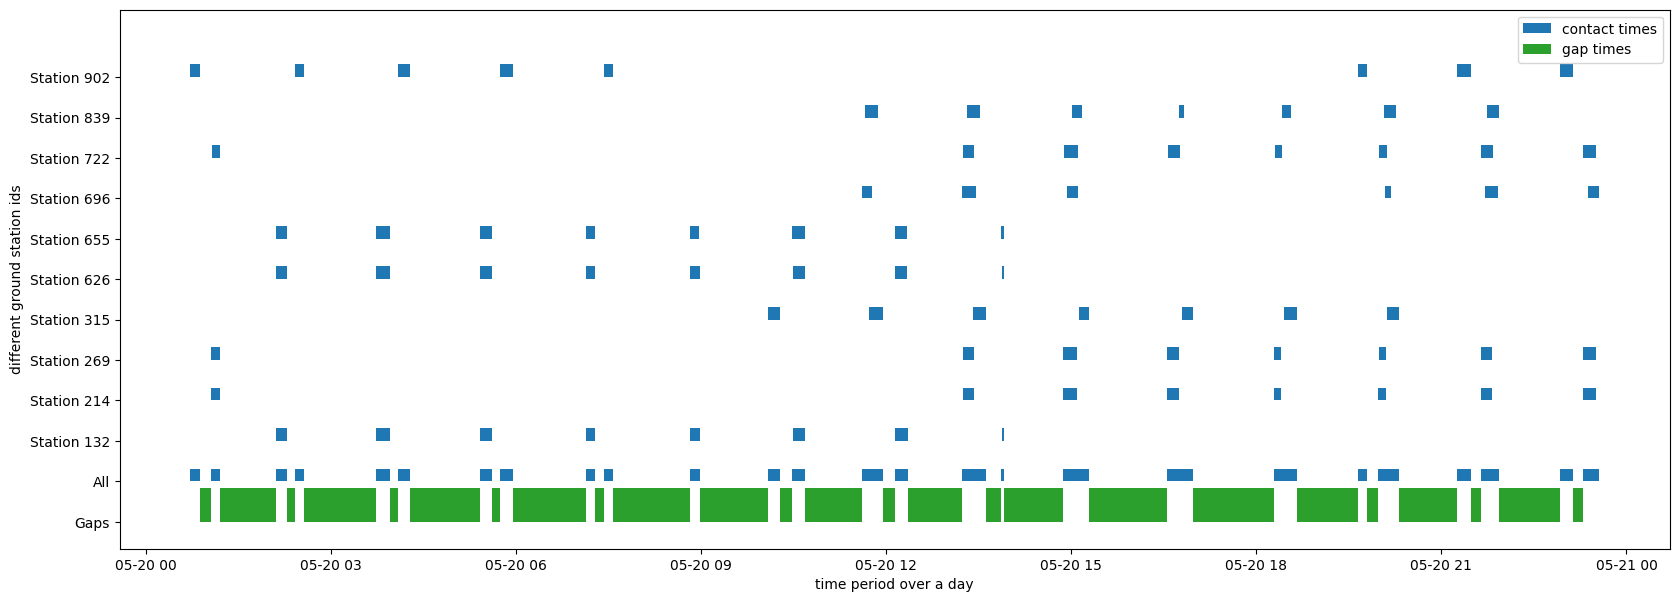

In [125]:
fig, ax = plt.subplots(figsize=(20,7))

selected_station_ids = [i for i in x if x[i].X == 1]
contacts_all = []

for idx in range(len(selected_station_ids)):
    station_id = selected_station_ids[idx]
    contacts = [contact for contact, sid, station in station_contacts[station_id]]
    for contact in contacts:
        contacts_all.append(contact)
    ax.broken_barh([(contact.t_start, contact.t_end-contact.t_start)
                    for contact in contacts],
                    (idx*3, 0.95), facecolors='tab:blue')
ax.broken_barh([(contact.t_start, contact.t_end-contact.t_start)
                for contact in contacts_all],
                (-3, 0.95),
                facecolors='tab:blue',
                label="contact times")
sorted_contacts = sorted(contacts_all, key=lambda t: t.t_start)
all_gap_times = []

current_t_end = sorted_contacts[0].t_end
for contact in sorted_contacts:
    if current_t_end < contact.t_end and current_t_end > contact.t_start:
        current_t_end = contact.t_end
    if current_t_end < contact.t_start:
        all_gap_times.append((current_t_end, contact.t_start))
        current_t_end = contact.t_end

# Plot gaps
ax.broken_barh([(gap[0], gap[1]-gap[0]) 
                for gap in all_gap_times], 
                (-6, 2.5), facecolors='tab:green',label="gap times")



ax.set_yticks(range(-6, len(selected_station_ids)*3, 3))
ax.set_yticklabels(['Gaps', 'All'] + [f'Station {sid}' for sid in selected_station_ids])

ax.set_ylim(-8, len(selected_station_ids)*3 + 2)
plt.ylabel("different ground station ids")
plt.xlabel("time period over a day")
plt.legend()
plt.show()

   
    